# Progetto di Apprendimento Automatico e Apprendimento Profondo

**Studente:** Vincenzo Esposito  
**Matricola:** 0322500120  
**Corso di Laurea Magistrale:** LM-32  
**Anno Accademico:** 2025/2026

## Classificazione del Breast Cancer Wisconsin (Diagnostic)

Il progetto utilizza il dataset **Breast Cancer Wisconsin (Diagnostic)** del repository UCI per sviluppare un esperimento di classificazione binaria.

L'obiettivo è distinguere i campioni **benigni (B)** dai campioni **maligni (M)** mediante:
- analisi delle feature con PCA;
- Logistic Regression;
- Support Vector Machine (SVM);
- Random Forest;
- rete neurale feed-forward con TensorFlow/Keras;
- valutazione tramite Accuracy, Precision, Recall, F1-score, ROC AUC, matrici di confusione e curve ROC.

Il dataset viene suddiviso in **70% training, 20% validation e 10% test**, mantenendo la distribuzione delle classi mediante stratificazione.


In [118]:
!pip install ucimlrepo -q

In [119]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from ucimlrepo import fetch_ucirepo

In [120]:
# Caricamento del dataset Breast Cancer Wisconsin (Diagnostic) da UCI
breast_cancer = fetch_ucirepo(id=17)

# Separazione tra feature e target
X = breast_cancer.data.features
y = breast_cancer.data.targets

print("Dimensioni delle feature X:", X.shape)
print("Dimensioni del target y:", y.shape)

Dimensioni delle feature X: (569, 30)
Dimensioni del target y: (569, 1)


In [121]:
# Visualizzazione delle prime righe delle feature
X.head()

,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [122]:
# Visualizzazione delle prime righe del target
y.head()

,Diagnosis
0,M
1,M
2,M
3,M
4,M


In [123]:
print("Numero totale di valori mancanti:")
print(X.isnull().sum().sum())

Numero totale di valori mancanti:
0


In [124]:
print("Distribuzione delle classi:")
print(y["Diagnosis"].value_counts())

Distribuzione delle classi:
Diagnosis
B    357
M    212
Name: count, dtype: int64


In [125]:
# Codifica del target:
# B = Benigno -> 0
# M = Maligno -> 1

y_encoded = y["Diagnosis"].map({
    "B": 0,
    "M": 1
})

print("Prime 10 etichette codificate:")
print(y_encoded.head(10))

print("\nDistribuzione delle classi dopo la codifica:")
print(y_encoded.value_counts())

Prime 10 etichette codificate:
0    1
1    1
2    1
3    1
4    1
5    1
6    1
7    1
8    1
9    1
Name: Diagnosis, dtype: int64

Distribuzione delle classi dopo la codifica:
Diagnosis
0    357
1    212
Name: count, dtype: int64


In [126]:
from sklearn.model_selection import train_test_split

In [127]:
# Prima suddivisione:
# 70% Training
# 30% dati temporanei, che saranno successivamente divisi
# in Validation e Test

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y_encoded,
    test_size=0.30,
    random_state=42,
    stratify=y_encoded
)

In [128]:
# Seconda suddivisione:
# il 30% temporaneo viene diviso in:
# 20% Validation
# 10% Test

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=1/3,
    random_state=42,
    stratify=y_temp
)

In [129]:
print("Dimensione Training set:", X_train.shape)
print("Dimensione Validation set:", X_val.shape)
print("Dimensione Test set:", X_test.shape)

print("\nNumero totale campioni:")
print(len(X_train) + len(X_val) + len(X_test))

Dimensione Training set: (398, 30)
Dimensione Validation set: (114, 30)
Dimensione Test set: (57, 30)

Numero totale campioni:
569


In [130]:
print("Distribuzione classi - TRAINING")
print(y_train.value_counts(normalize=True))

print("\nDistribuzione classi - VALIDATION")
print(y_val.value_counts(normalize=True))

print("\nDistribuzione classi - TEST")
print(y_test.value_counts(normalize=True))

Distribuzione classi - TRAINING
Diagnosis
0    0.628141
1    0.371859
Name: proportion, dtype: float64

Distribuzione classi - VALIDATION
Diagnosis
0    0.622807
1    0.377193
Name: proportion, dtype: float64

Distribuzione classi - TEST
Diagnosis
0    0.631579
1    0.368421
Name: proportion, dtype: float64


## Analisi delle feature mediante PCA

In [131]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [132]:
# Standardizzazione delle feature prima dell'applicazione della PCA

scaler_pca = StandardScaler()
X_scaled_pca = scaler_pca.fit_transform(X)

print("Dimensioni dei dati standardizzati:", X_scaled_pca.shape)

Dimensioni dei dati standardizzati: (569, 30)


In [133]:
# Applicazione della PCA con due componenti principali

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled_pca)

print("Dimensioni dopo la PCA:", X_pca.shape)

Dimensioni dopo la PCA: (569, 2)


In [134]:
print("Varianza spiegata da PC1:",
      pca.explained_variance_ratio_[0])

print("Varianza spiegata da PC2:",
      pca.explained_variance_ratio_[1])

print("Varianza totale spiegata dalle prime due componenti:",
      pca.explained_variance_ratio_.sum())

Varianza spiegata da PC1: 0.44272025607526366
Varianza spiegata da PC2: 0.18971182044033078
Varianza totale spiegata dalle prime due componenti: 0.6324320765155944


In [135]:
# Creazione di un DataFrame contenente le due componenti principali

pca_df = pd.DataFrame(
    data=X_pca,
    columns=["PC1", "PC2"]
)

# Aggiunta della diagnosi
pca_df["Diagnosis"] = y_encoded.values

pca_df.head()

,PC1,PC2,Diagnosis
0,9.192837,1.948583,1
1,2.387802,-3.768172,1
2,5.733896,-1.075174,1
3,7.122953,10.275589,1
4,3.935302,-1.948072,1


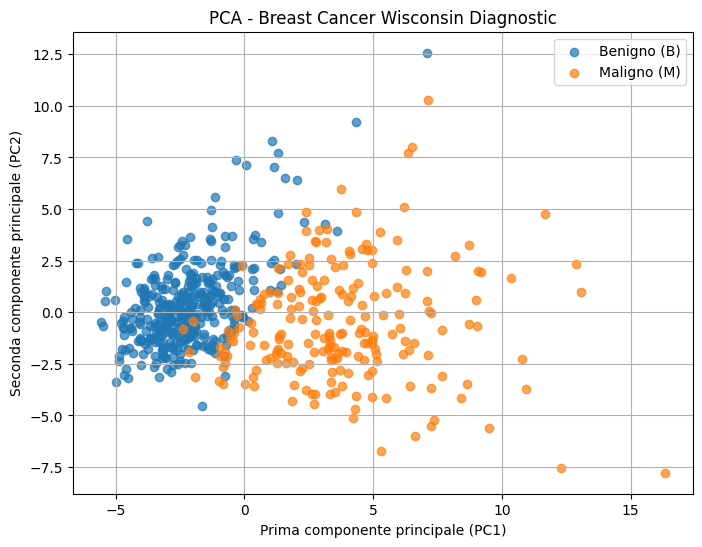

In [136]:
# Visualizzazione delle prime due componenti principali

plt.figure(figsize=(8, 6))

# Campioni benigni
plt.scatter(
    pca_df[pca_df["Diagnosis"] == 0]["PC1"],
    pca_df[pca_df["Diagnosis"] == 0]["PC2"],
    label="Benigno (B)",
    alpha=0.7
)

# Campioni maligni
plt.scatter(
    pca_df[pca_df["Diagnosis"] == 1]["PC1"],
    pca_df[pca_df["Diagnosis"] == 1]["PC2"],
    label="Maligno (M)",
    alpha=0.7
)

plt.xlabel("Prima componente principale (PC1)")
plt.ylabel("Seconda componente principale (PC2)")
plt.title("PCA - Breast Cancer Wisconsin Diagnostic")

plt.legend()
plt.grid()

plt.show()

### Interpretazione della PCA

Le prime due componenti principali spiegano complessivamente circa il 63,24% della
varianza totale del dataset. Dal grafico si osserva una parziale separazione tra i campioni
benigni e maligni, soprattutto lungo la prima componente principale (PC1).
È comunque presente una zona di sovrapposizione tra le due classi, indicando che le prime
due componenti non consentono una separazione completa dei campioni.

## Algoritmi di classificazione

### Preprocessing dei dati per la classificazione

In [137]:
# Standardizzazione dei dati per gli algoritmi di classificazione

scaler = StandardScaler()

# Lo scaler viene addestrato esclusivamente sul training set
X_train_scaled = scaler.fit_transform(X_train)

# La stessa trasformazione viene applicata a validation e test
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Training:", X_train_scaled.shape)
print("Validation:", X_val_scaled.shape)
print("Test:", X_test_scaled.shape)

Training: (398, 30)
Validation: (114, 30)
Test: (57, 30)


### 1. Logistic Regression

In [138]:
from sklearn.linear_model import LogisticRegression

# Creazione del modello
logistic_model = LogisticRegression(max_iter=1000)

# Addestramento sul training set
logistic_model.fit(X_train_scaled, y_train)

print("Addestramento Logistic Regression completato.")

Addestramento Logistic Regression completato.


In [139]:
# Predizioni sul validation set
y_val_pred_logistic = logistic_model.predict(X_val_scaled)

# Probabilità della classe positiva: Maligno = 1
y_val_prob_logistic = logistic_model.predict_proba(X_val_scaled)[:, 1]

print("Prime 10 predizioni:")
print(y_val_pred_logistic[:10])

print("\nPrime 10 probabilità di malignità:")
print(y_val_prob_logistic[:10])

Prime 10 predizioni:
[0 0 0 0 0 0 0 0 0 0]

Prime 10 probabilità di malignità:
[7.88291207e-02 2.09746679e-03 3.61643683e-05 4.44757227e-03
 4.07108044e-04 7.24088689e-03 7.55607079e-02 1.95037877e-03
 4.90396362e-03 2.70141317e-04]


In [140]:
# Confronto tra valori reali e predizioni
confronto_logistic = pd.DataFrame({
    "Reale": y_val.values,
    "Predetto": y_val_pred_logistic,
    "Probabilita_Maligno": y_val_prob_logistic
})

confronto_logistic.head(10)

,Reale,Predetto,Probabilita_Maligno
0,0,0,0.078829
1,0,0,0.002097
2,0,0,0.000036
3,0,0,0.004448
4,0,0,0.000407
5,0,0,0.007241
6,0,0,0.075561
7,0,0,0.001950
8,0,0,0.004904
9,0,0,0.000270


In [141]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Calcolo delle metriche sul validation set
accuracy_logistic = accuracy_score(y_val, y_val_pred_logistic)
precision_logistic = precision_score(y_val, y_val_pred_logistic)
recall_logistic = recall_score(y_val, y_val_pred_logistic)
f1_logistic = f1_score(y_val, y_val_pred_logistic)
roc_auc_logistic = roc_auc_score(y_val, y_val_prob_logistic)

print("Logistic Regression - Validation Set")
print("-------------------------------------")
print(f"Accuracy:  {accuracy_logistic:.4f}")
print(f"Precision: {precision_logistic:.4f}")
print(f"Recall:    {recall_logistic:.4f}")
print(f"F1-score:  {f1_logistic:.4f}")
print(f"ROC AUC:   {roc_auc_logistic:.4f}")

Logistic Regression - Validation Set
-------------------------------------
Accuracy:  0.9649
Precision: 0.9756
Recall:    0.9302
F1-score:  0.9524
ROC AUC:   0.9961


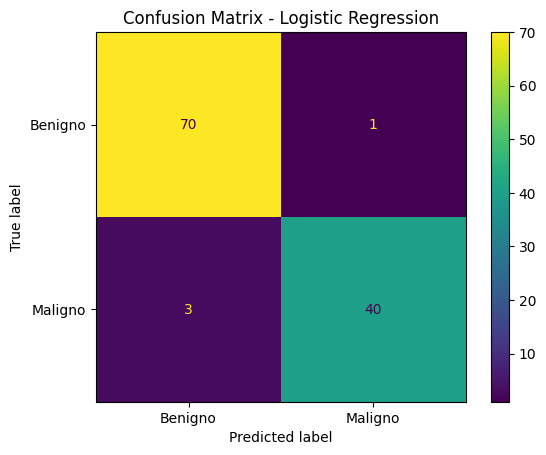

In [142]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Calcolo della matrice di confusione
cm_logistic = confusion_matrix(y_val, y_val_pred_logistic)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_logistic,
    display_labels=["Benigno", "Maligno"]
)

disp.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

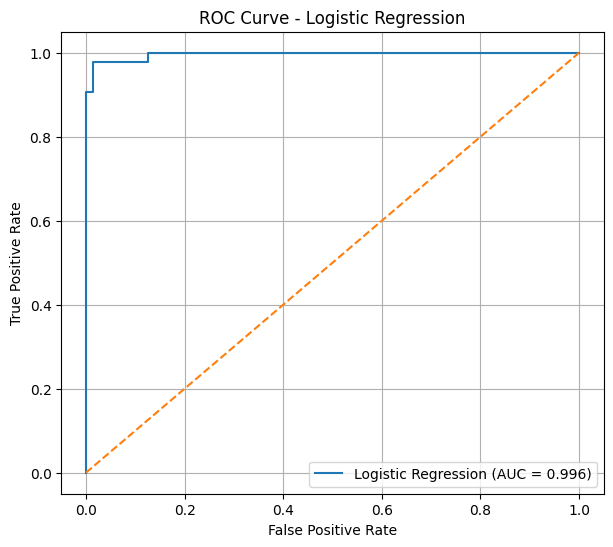

In [143]:
from sklearn.metrics import roc_curve

# Calcolo dei punti della curva ROC
fpr_logistic, tpr_logistic, thresholds_logistic = roc_curve(
    y_val,
    y_val_prob_logistic
)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr_logistic,
    tpr_logistic,
    label=f"Logistic Regression (AUC = {roc_auc_logistic:.3f})"
)

# Linea del classificatore casuale
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.grid()

plt.show()

### Interpretazione dei risultati - Logistic Regression

La Logistic Regression ha ottenuto prestazioni elevate sul validation set, con un'Accuracy
pari a circa 96,49%, una Precision del 97,56%, un Recall del 93,02% e un F1-score del
95,24%. La ROC AUC è pari a circa 0,996, indicando un'elevata capacità del modello di
discriminare tra campioni benigni e maligni.

Dalla matrice di confusione risultano 70 veri negativi, 40 veri positivi, 1 falso positivo
e 3 falsi negativi. Il modello presenta quindi un numero limitato di errori di classificazione.

### 2. Support Vector Machine (SVM)

In [144]:
from sklearn.svm import SVC

# Creazione del modello SVM con kernel RBF
svm_model = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale"
)

# Addestramento sul training set
svm_model.fit(X_train_scaled, y_train)

print("Addestramento SVM completato.")

Addestramento SVM completato.


In [145]:
# Predizioni sul validation set
y_val_pred_svm = svm_model.predict(X_val_scaled)

# Score continuo per il calcolo della ROC AUC
y_val_score_svm = svm_model.decision_function(X_val_scaled)

print("Prime 10 predizioni:")
print(y_val_pred_svm[:10])

print("\nPrimi 10 score SVM:")
print(y_val_score_svm[:10])

Prime 10 predizioni:
[0 0 0 0 0 0 0 0 0 0]

Primi 10 score SVM:
[-1.11610087 -1.98126476 -2.05475919 -1.52734922 -2.29092754 -1.69120237
 -1.34406405 -1.93095524 -1.39616967 -2.07918767]


In [146]:
accuracy_svm = accuracy_score(y_val, y_val_pred_svm)
precision_svm = precision_score(y_val, y_val_pred_svm)
recall_svm = recall_score(y_val, y_val_pred_svm)
f1_svm = f1_score(y_val, y_val_pred_svm)
roc_auc_svm = roc_auc_score(y_val, y_val_score_svm)

print("Support Vector Machine - Validation Set")
print("---------------------------------------")
print(f"Accuracy:  {accuracy_svm:.4f}")
print(f"Precision: {precision_svm:.4f}")
print(f"Recall:    {recall_svm:.4f}")
print(f"F1-score:  {f1_svm:.4f}")
print(f"ROC AUC:   {roc_auc_svm:.4f}")

Support Vector Machine - Validation Set
---------------------------------------
Accuracy:  0.9561
Precision: 1.0000
Recall:    0.8837
F1-score:  0.9383
ROC AUC:   0.9954


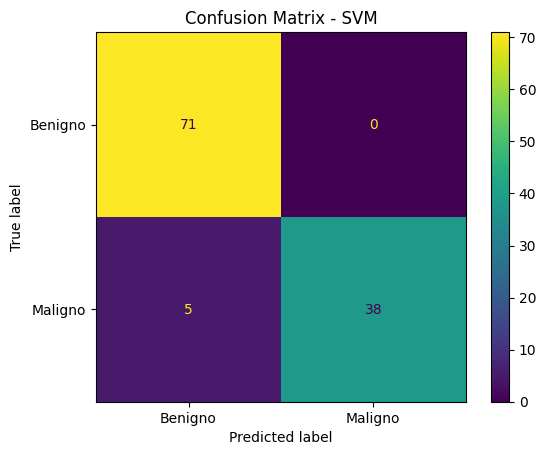

In [147]:
cm_svm = confusion_matrix(y_val, y_val_pred_svm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_svm,
    display_labels=["Benigno", "Maligno"]
)

disp.plot()
plt.title("Confusion Matrix - SVM")
plt.show()

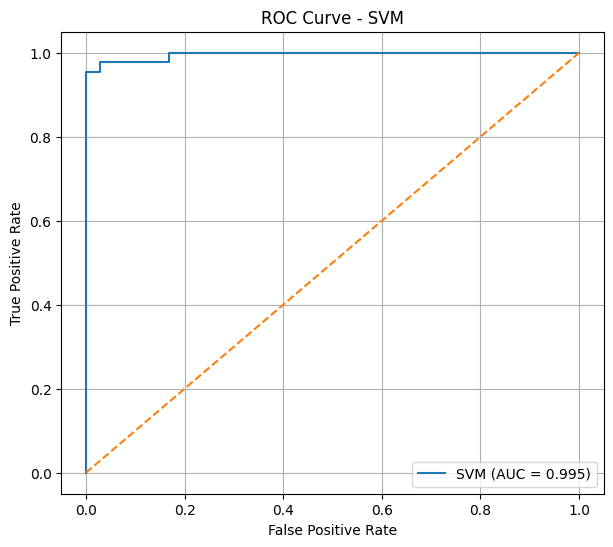

In [148]:
fpr_svm, tpr_svm, thresholds_svm = roc_curve(
    y_val,
    y_val_score_svm
)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr_svm,
    tpr_svm,
    label=f"SVM (AUC = {roc_auc_svm:.3f})"
)

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - SVM")
plt.legend()
plt.grid()

plt.show()

### Interpretazione dei risultati - Support Vector Machine

La Support Vector Machine ha ottenuto prestazioni elevate sul validation set, con
un'Accuracy pari a circa 95,61%, una Precision del 100%, un Recall dell'88,37% e
un F1-score del 93,83%. La ROC AUC è pari a circa 0,995, mostrando un'elevata
capacità discriminante tra le due classi.

La matrice di confusione evidenzia 71 veri negativi, 38 veri positivi, nessun falso
positivo e 5 falsi negativi. Il modello risulta quindi molto preciso nell'identificazione
dei campioni classificati come maligni, ma presenta un Recall inferiore rispetto alla
Logistic Regression a causa dei cinque campioni maligni classificati come benigni.

### 3. Random Forest

In [149]:
from sklearn.ensemble import RandomForestClassifier

# Creazione del modello Random Forest
random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Addestramento sul training set
random_forest_model.fit(X_train, y_train)

print("Addestramento Random Forest completato.")

Addestramento Random Forest completato.


In [150]:
# Predizioni sul validation set
y_val_pred_rf = random_forest_model.predict(X_val)

# Probabilità della classe positiva: Maligno = 1
y_val_prob_rf = random_forest_model.predict_proba(X_val)[:, 1]

print("Prime 10 predizioni:")
print(y_val_pred_rf[:10])

print("\nPrime 10 probabilità di malignità:")
print(y_val_prob_rf[:10])

Prime 10 predizioni:
[0 0 0 0 0 0 0 0 0 0]

Prime 10 probabilità di malignità:
[0.08 0.   0.   0.04 0.02 0.   0.01 0.01 0.17 0.  ]


In [151]:
accuracy_rf = accuracy_score(y_val, y_val_pred_rf)
precision_rf = precision_score(y_val, y_val_pred_rf)
recall_rf = recall_score(y_val, y_val_pred_rf)
f1_rf = f1_score(y_val, y_val_pred_rf)
roc_auc_rf = roc_auc_score(y_val, y_val_prob_rf)

print("Random Forest - Validation Set")
print("--------------------------------")
print(f"Accuracy:  {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall:    {recall_rf:.4f}")
print(f"F1-score:  {f1_rf:.4f}")
print(f"ROC AUC:   {roc_auc_rf:.4f}")

Random Forest - Validation Set
--------------------------------
Accuracy:  0.9561
Precision: 1.0000
Recall:    0.8837
F1-score:  0.9383
ROC AUC:   0.9949


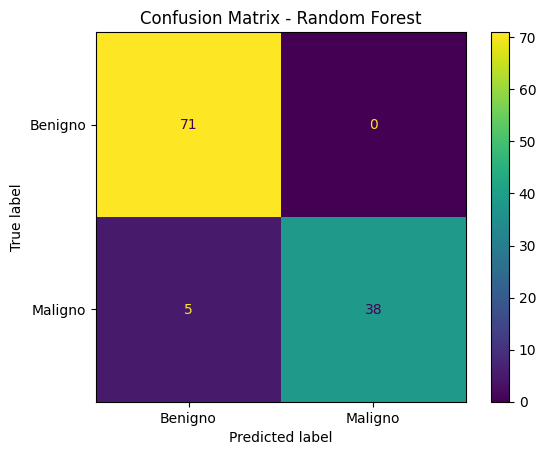

In [152]:
cm_rf = confusion_matrix(y_val, y_val_pred_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["Benigno", "Maligno"]
)

disp.plot()
plt.title("Confusion Matrix - Random Forest")
plt.show()

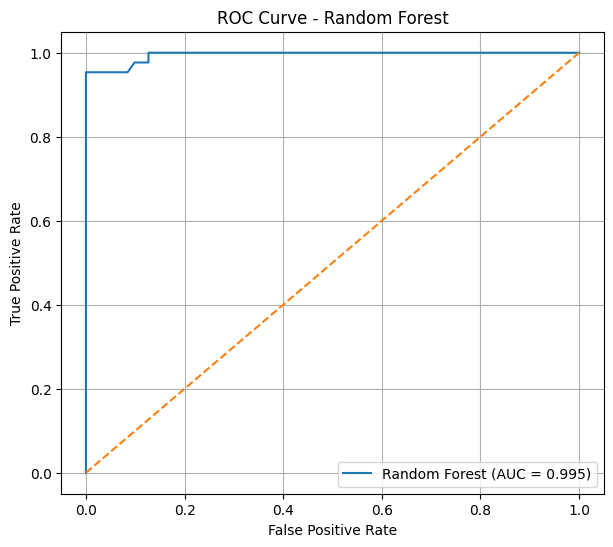

In [153]:
fpr_rf, tpr_rf, thresholds_rf = roc_curve(
    y_val,
    y_val_prob_rf
)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {roc_auc_rf:.3f})"
)

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.grid()

plt.show()

### Interpretazione dei risultati - Random Forest

La Random Forest ha ottenuto prestazioni elevate sul validation set, con un'Accuracy
pari a circa 95,61%, una Precision del 100%, un Recall dell'88,37% e un F1-score
del 93,83%. La ROC AUC è pari a circa 0,995, evidenziando un'elevata capacità
discriminante tra campioni benigni e maligni.

La matrice di confusione mostra 71 veri negativi, 38 veri positivi, nessun falso
positivo e 5 falsi negativi. Sul validation set il modello presenta quindi le stesse
classificazioni finali ottenute dalla Support Vector Machine.

## Confronto degli algoritmi shallow

In [154]:
# Tabella comparativa dei risultati sul validation set

risultati_shallow = pd.DataFrame({
    "Modello": [
        "Logistic Regression",
        "SVM",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_logistic,
        accuracy_svm,
        accuracy_rf
    ],
    "Precision": [
        precision_logistic,
        precision_svm,
        precision_rf
    ],
    "Recall": [
        recall_logistic,
        recall_svm,
        recall_rf
    ],
    "F1-score": [
        f1_logistic,
        f1_svm,
        f1_rf
    ],
    "ROC AUC": [
        roc_auc_logistic,
        roc_auc_svm,
        roc_auc_rf
    ]
})

risultati_shallow.round(4)

,Modello,Accuracy,Precision,Recall,F1-score,ROC AUC
0,Logistic Regression,0.9649,0.9756,0.9302,0.9524,0.9961
1,SVM,0.9561,1.0000,0.8837,0.9383,0.9954
2,Random Forest,0.9561,1.0000,0.8837,0.9383,0.9949


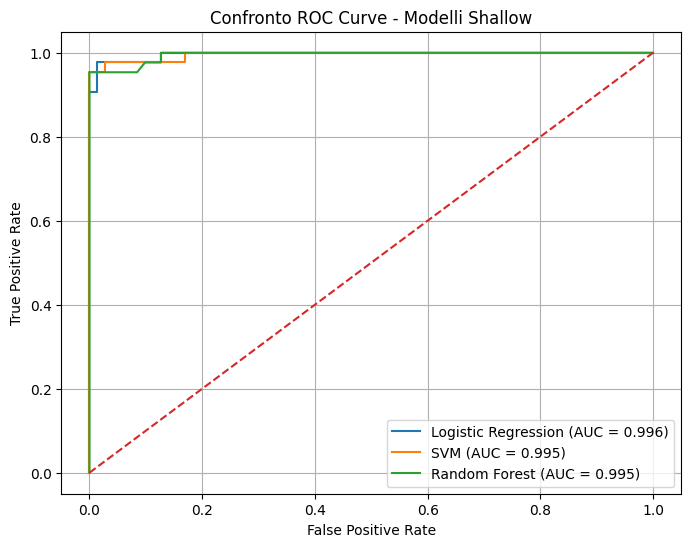

In [155]:
plt.figure(figsize=(8, 6))

plt.plot(
    fpr_logistic,
    tpr_logistic,
    label=f"Logistic Regression (AUC = {roc_auc_logistic:.3f})"
)

plt.plot(
    fpr_svm,
    tpr_svm,
    label=f"SVM (AUC = {roc_auc_svm:.3f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {roc_auc_rf:.3f})"
)

# Classificatore casuale
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Confronto ROC Curve - Modelli Shallow")
plt.legend()
plt.grid()

plt.show()

### Confronto dei modelli shallow

Tutti e tre i classificatori hanno ottenuto prestazioni elevate sul validation set.

La Logistic Regression presenta la maggiore Accuracy (96,49%), il maggiore Recall
(93,02%) e il maggiore F1-score (95,24%). SVM e Random Forest raggiungono invece
una Precision del 100%, non producendo falsi positivi nel validation set, ma presentano
un Recall inferiore (88,37%) a causa di cinque campioni maligni classificati come benigni.

I valori di ROC AUC risultano molto elevati per tutti i modelli, con valori prossimi a 1.
Tra i tre classificatori, la Logistic Regression presenta il valore di ROC AUC
leggermente maggiore.

## Approccio Deep Learning

Per il confronto con gli algoritmi shallow viene implementata una rete neurale
feed-forward mediante TensorFlow/Keras. La rete utilizza gli stessi training,
validation e test set definiti precedentemente.

In [156]:
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense

# Seed per rendere l'esperimento più riproducibile
tf.random.set_seed(42)
np.random.seed(42)

print("Versione TensorFlow:", tf.__version__)

Versione TensorFlow: 2.20.0


In [157]:
# Creazione della rete neurale

deep_model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(16, activation="relu"),
    Dense(8, activation="relu"),
    Dense(1, activation="sigmoid")
])

deep_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 16)             │           496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 641 (2.50 KB)

 Trainable params: 641 (2.50 KB)

 Non-trainable params: 0 (0.00 B)

In [158]:
# Compilazione della rete neurale

deep_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Compilazione del modello completata.")

Compilazione del modello completata.


In [159]:
# Addestramento della rete neurale

history = deep_model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.5704 - loss: 0.6700 - val_accuracy: 0.7193 - val_loss: 0.6248
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8191 - loss: 0.5403 - val_accuracy: 0.8772 - val_loss: 0.5192
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8970 - loss: 0.4488 - val_accuracy: 0.8947 - val_loss: 0.4347
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9196 - loss: 0.3793 - val_accuracy: 0.9211 - val_loss: 0.3715
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.9472 - loss: 0.3246 - val_accuracy: 0.9386 - val_loss: 0.3199
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.9472 - loss: 0.2785 - val_accuracy: 0.9474 - val_loss: 0.2749
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9523 - loss: 0.2389 - val_accuracy: 0.9649 - val_loss: 0.2356
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9573 - loss: 0.2067 - val_accuracy: 0.9649 - v

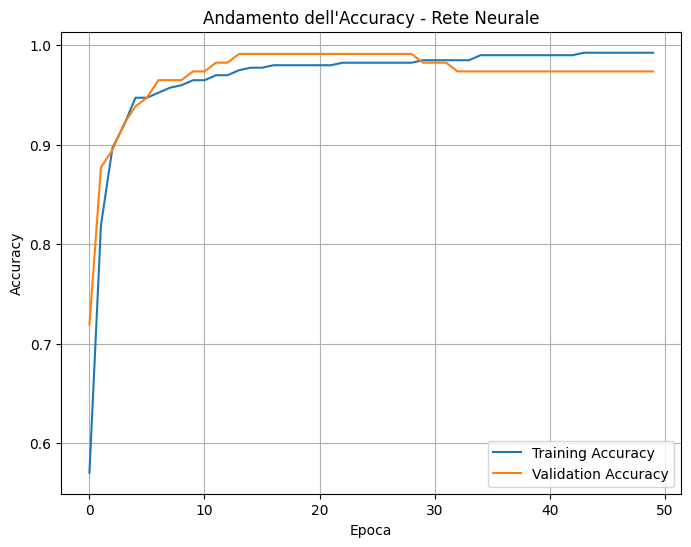

In [160]:
# Andamento dell'Accuracy durante l'addestramento

plt.figure(figsize=(8, 6))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoca")
plt.ylabel("Accuracy")
plt.title("Andamento dell'Accuracy - Rete Neurale")
plt.legend()
plt.grid()

plt.show()

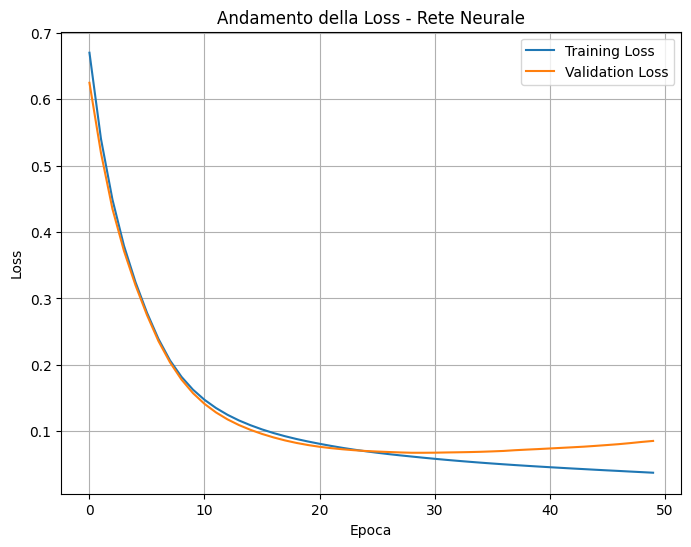

In [161]:
# Andamento della Loss durante l'addestramento

plt.figure(figsize=(8, 6))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoca")
plt.ylabel("Loss")
plt.title("Andamento della Loss - Rete Neurale")
plt.legend()
plt.grid()

plt.show()

In [162]:
best_val_accuracy = max(history.history["val_accuracy"])
best_epoch = np.argmax(history.history["val_accuracy"]) + 1

print(f"Migliore Validation Accuracy: {best_val_accuracy:.4f}")
print(f"Ottenuta all'epoca: {best_epoch}")

Migliore Validation Accuracy: 0.9912
Ottenuta all'epoca: 14


### Interpretazione dell'addestramento della rete neurale

L'andamento dell'Accuracy mostra un rapido miglioramento sia sul training set sia sul validation set durante le prime epoche. Nell'esecuzione completa del notebook, la migliore **Validation Accuracy** osservata è pari al **99,12%**, raggiunta per la prima volta all'epoca **14** e mantenuta per diverse epoche successive.

La training loss continua a diminuire durante tutto l'addestramento, mentre la validation loss raggiunge i valori più bassi intorno alla parte centrale dell'addestramento e successivamente tende ad aumentare. Parallelamente, nelle ultime epoche la Training Accuracy continua a migliorare mentre la Validation Accuracy diminuisce leggermente.

Questo andamento evidenzia un lieve fenomeno di overfitting nelle fasi finali. Poiché il plateau delle prestazioni di validazione inizia già intorno alle epoche 14-15, per il modello finale viene utilizzato un addestramento più breve di **15 epoche**, evitando di proseguire fino alle fasi in cui la divergenza tra training e validation diventa più evidente.


### Modello Deep Learning selezionato

In [105]:
# Ricreazione della stessa architettura utilizzando
# il numero di epoche selezionato tramite il validation set

tf.keras.backend.clear_session()

tf.random.set_seed(42)
np.random.seed(42)

deep_model_selected = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(16, activation="relu"),
    Dense(8, activation="relu"),
    Dense(1, activation="sigmoid")
])

deep_model_selected.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_selected = deep_model_selected.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=15,
    batch_size=32,
    verbose=1
)

Epoch 1/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - accuracy: 0.5854 - loss: 0.7074 - val_accuracy: 0.7105 - val_loss: 0.6426
Epoch 2/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.7764 - loss: 0.6179 - val_accuracy: 0.8509 - val_loss: 0.5601
Epoch 3/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.8643 - loss: 0.5386 - val_accuracy: 0.8860 - val_loss: 0.4866
Epoch 4/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9095 - loss: 0.4562 - val_accuracy: 0.9035 - val_loss: 0.4137
Epoch 5/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.9171 - loss: 0.3758 - val_accuracy: 0.9035 - val_loss: 0.3461
Epoch 6/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9221 - loss: 0.3084 - val_accuracy: 0.9035 - val_loss: 0.2906
Epoch 7/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9322 - loss: 0.2577 - val_accuracy: 0.9123 - val_loss: 0.2482
Epoch 8/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9422 - loss: 0.2214 - val_accuracy: 0.9298 - v

In [106]:
# Probabilità previste sul validation set
y_val_prob_deep = deep_model_selected.predict(
    X_val_scaled
).ravel()

# Conversione delle probabilità in classi
# soglia 0.5: >= 0.5 Maligno, < 0.5 Benigno
y_val_pred_deep = (y_val_prob_deep >= 0.5).astype(int)

print("Prime 10 probabilità:")
print(y_val_prob_deep[:10])

print("\nPrime 10 predizioni:")
print(y_val_pred_deep[:10])

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Prime 10 probabilità:
[0.02665468 0.01438465 0.00080122 0.03463421 0.00962854 0.02344828
 0.30110905 0.01531687 0.1104055  0.01072001]

Prime 10 predizioni:
[0 0 0 0 0 0 0 0 0 0]


In [107]:
accuracy_deep = accuracy_score(y_val, y_val_pred_deep)
precision_deep = precision_score(y_val, y_val_pred_deep)
recall_deep = recall_score(y_val, y_val_pred_deep)
f1_deep = f1_score(y_val, y_val_pred_deep)
roc_auc_deep = roc_auc_score(y_val, y_val_prob_deep)

print("Deep Learning - Validation Set")
print("--------------------------------")
print(f"Accuracy:  {accuracy_deep:.4f}")
print(f"Precision: {precision_deep:.4f}")
print(f"Recall:    {recall_deep:.4f}")
print(f"F1-score:  {f1_deep:.4f}")
print(f"ROC AUC:   {roc_auc_deep:.4f}")

Deep Learning - Validation Set
--------------------------------
Accuracy:  0.9737
Precision: 0.9545
Recall:    0.9767
F1-score:  0.9655
ROC AUC:   0.9938


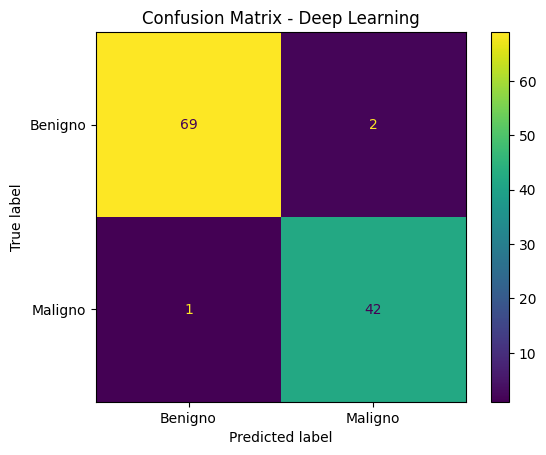

In [108]:
cm_deep = confusion_matrix(y_val, y_val_pred_deep)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_deep,
    display_labels=["Benigno", "Maligno"]
)

disp.plot()
plt.title("Confusion Matrix - Deep Learning")
plt.show()

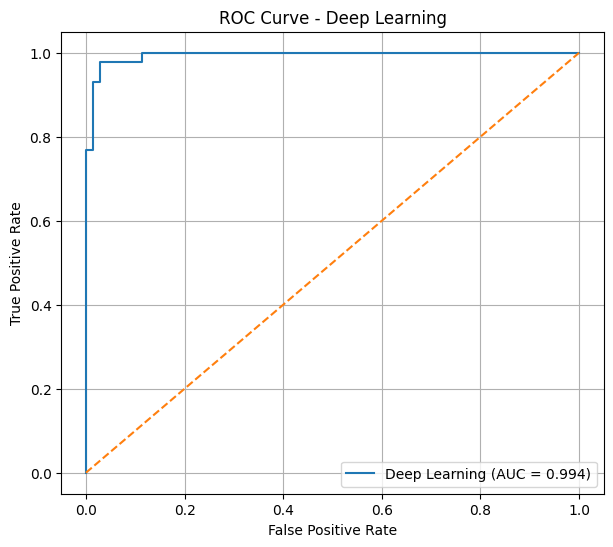

In [109]:
fpr_deep, tpr_deep, thresholds_deep = roc_curve(
    y_val,
    y_val_prob_deep
)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr_deep,
    tpr_deep,
    label=f"Deep Learning (AUC = {roc_auc_deep:.3f})"
)

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Deep Learning")
plt.legend()
plt.grid()

plt.show()

### Interpretazione dei risultati - Deep Learning

Il modello di Deep Learning selezionato ha ottenuto prestazioni elevate sul validation set, con un'**Accuracy del 97,37%**, una **Precision del 95,45%**, un **Recall del 97,67%**, un **F1-score del 96,55%** e una **ROC AUC del 99,38%**.

La matrice di confusione mostra **69 veri negativi**, **42 veri positivi**, **2 falsi positivi** e **1 falso negativo**. Il modello ha quindi classificato correttamente **111 dei 114 campioni** presenti nel validation set.

Il confronto con gli algoritmi shallow mostra che la rete neurale raggiunge prestazioni competitive, con un Recall particolarmente elevato sul validation set.


## Valutazione finale sul Test Set

Dopo aver completato l'addestramento e la validazione dei modelli, viene effettuata
la valutazione finale sul test set, costituito da dati mai utilizzati durante le fasi
precedenti di training e validazione.

In [110]:
# Logistic Regression - Test Set

y_test_pred_logistic = logistic_model.predict(X_test_scaled)
y_test_prob_logistic = logistic_model.predict_proba(X_test_scaled)[:, 1]

In [111]:
# Support Vector Machine - Test Set

y_test_pred_svm = svm_model.predict(X_test_scaled)
y_test_score_svm = svm_model.decision_function(X_test_scaled)

In [112]:
# Random Forest - Test Set

y_test_pred_rf = random_forest_model.predict(X_test)
y_test_prob_rf = random_forest_model.predict_proba(X_test)[:, 1]

In [113]:
# Deep Learning - Test Set

y_test_prob_deep = deep_model_selected.predict(
    X_test_scaled,
    verbose=0
).ravel()

y_test_pred_deep = (y_test_prob_deep >= 0.5).astype(int)

In [114]:
# Logistic Regression
accuracy_logistic_test = accuracy_score(y_test, y_test_pred_logistic)
precision_logistic_test = precision_score(y_test, y_test_pred_logistic)
recall_logistic_test = recall_score(y_test, y_test_pred_logistic)
f1_logistic_test = f1_score(y_test, y_test_pred_logistic)
roc_auc_logistic_test = roc_auc_score(y_test, y_test_prob_logistic)

# SVM
accuracy_svm_test = accuracy_score(y_test, y_test_pred_svm)
precision_svm_test = precision_score(y_test, y_test_pred_svm)
recall_svm_test = recall_score(y_test, y_test_pred_svm)
f1_svm_test = f1_score(y_test, y_test_pred_svm)
roc_auc_svm_test = roc_auc_score(y_test, y_test_score_svm)

# Random Forest
accuracy_rf_test = accuracy_score(y_test, y_test_pred_rf)
precision_rf_test = precision_score(y_test, y_test_pred_rf)
recall_rf_test = recall_score(y_test, y_test_pred_rf)
f1_rf_test = f1_score(y_test, y_test_pred_rf)
roc_auc_rf_test = roc_auc_score(y_test, y_test_prob_rf)

# Deep Learning
accuracy_deep_test = accuracy_score(y_test, y_test_pred_deep)
precision_deep_test = precision_score(y_test, y_test_pred_deep)
recall_deep_test = recall_score(y_test, y_test_pred_deep)
f1_deep_test = f1_score(y_test, y_test_pred_deep)
roc_auc_deep_test = roc_auc_score(y_test, y_test_prob_deep)

In [115]:
risultati_test = pd.DataFrame({
    "Modello": [
        "Logistic Regression",
        "SVM",
        "Random Forest",
        "Deep Learning"
    ],
    "Accuracy": [
        accuracy_logistic_test,
        accuracy_svm_test,
        accuracy_rf_test,
        accuracy_deep_test
    ],
    "Precision": [
        precision_logistic_test,
        precision_svm_test,
        precision_rf_test,
        precision_deep_test
    ],
    "Recall": [
        recall_logistic_test,
        recall_svm_test,
        recall_rf_test,
        recall_deep_test
    ],
    "F1-score": [
        f1_logistic_test,
        f1_svm_test,
        f1_rf_test,
        f1_deep_test
    ],
    "ROC AUC": [
        roc_auc_logistic_test,
        roc_auc_svm_test,
        roc_auc_rf_test,
        roc_auc_deep_test
    ]
})

risultati_test.round(4)

,Modello,Accuracy,Precision,Recall,F1-score,ROC AUC
0,Logistic Regression,0.9825,1.0,0.9524,0.9756,1.0
1,SVM,0.9649,1.0,0.9048,0.9500,1.0
2,Random Forest,0.9825,1.0,0.9524,0.9756,1.0
3,Deep Learning,0.9474,1.0,0.8571,0.9231,1.0


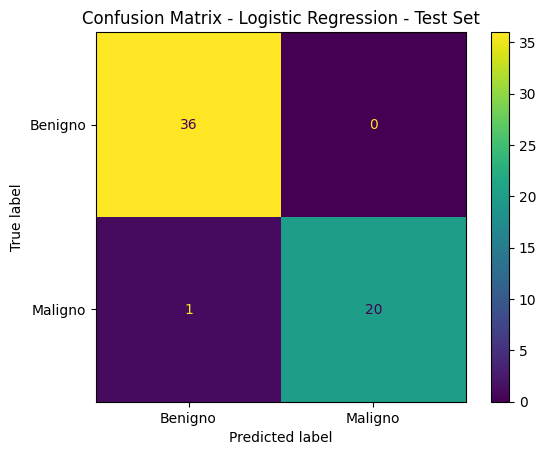

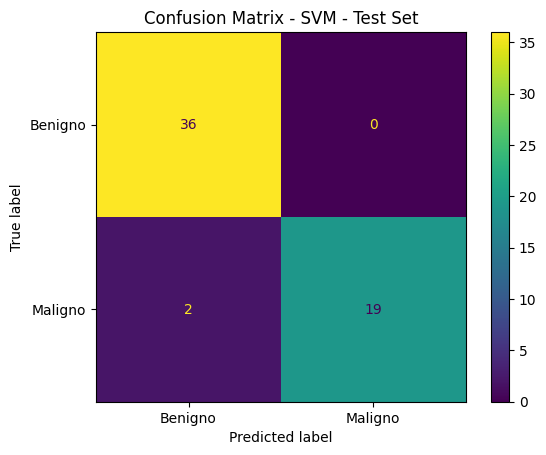

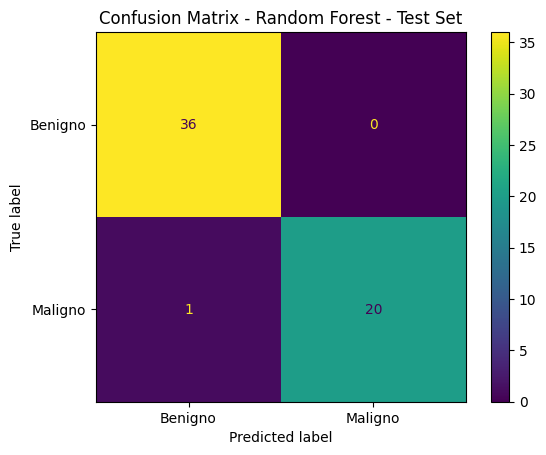

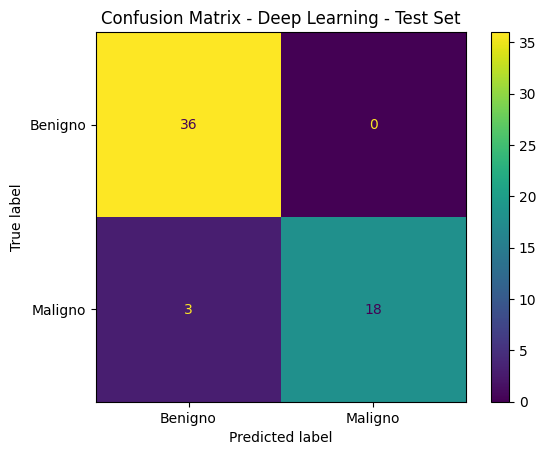

In [116]:
modelli_test = [
    ("Logistic Regression", y_test_pred_logistic),
    ("SVM", y_test_pred_svm),
    ("Random Forest", y_test_pred_rf),
    ("Deep Learning", y_test_pred_deep)
]

for nome, predizioni in modelli_test:
    cm = confusion_matrix(y_test, predizioni)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Benigno", "Maligno"]
    )

    disp.plot()
    plt.title(f"Confusion Matrix - {nome} - Test Set")
    plt.show()

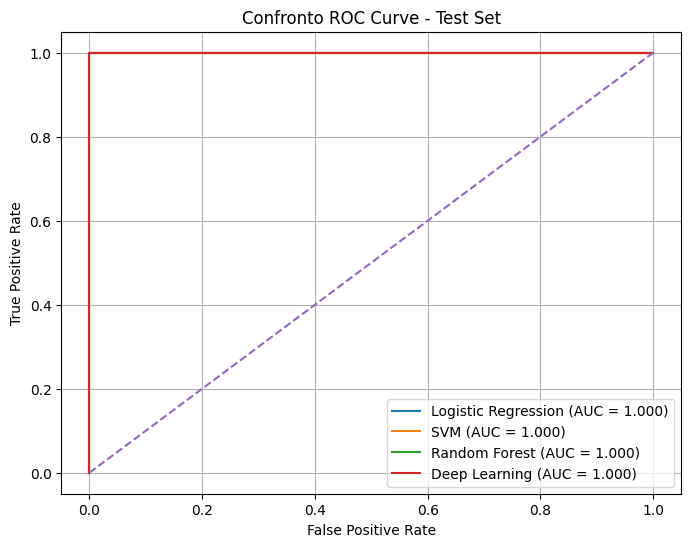

In [117]:
# Curve ROC sul Test Set

fpr_log_test, tpr_log_test, _ = roc_curve(
    y_test, y_test_prob_logistic
)

fpr_svm_test, tpr_svm_test, _ = roc_curve(
    y_test, y_test_score_svm
)

fpr_rf_test, tpr_rf_test, _ = roc_curve(
    y_test, y_test_prob_rf
)

fpr_deep_test, tpr_deep_test, _ = roc_curve(
    y_test, y_test_prob_deep
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_log_test,
    tpr_log_test,
    label=f"Logistic Regression (AUC = {roc_auc_logistic_test:.3f})"
)

plt.plot(
    fpr_svm_test,
    tpr_svm_test,
    label=f"SVM (AUC = {roc_auc_svm_test:.3f})"
)

plt.plot(
    fpr_rf_test,
    tpr_rf_test,
    label=f"Random Forest (AUC = {roc_auc_rf_test:.3f})"
)

plt.plot(
    fpr_deep_test,
    tpr_deep_test,
    label=f"Deep Learning (AUC = {roc_auc_deep_test:.3f})"
)

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Confronto ROC Curve - Test Set")
plt.legend()
plt.grid()

plt.show()

### Confronto finale sul Test Set

La valutazione finale è stata effettuata sul test set, costituito da **57 campioni** mai utilizzati durante le precedenti fasi di training e validazione.

**Logistic Regression** e **Random Forest** hanno ottenuto le migliori prestazioni finali: Accuracy del **98,25%**, Precision del **100%**, Recall del **95,24%** e F1-score del **97,56%**. Le rispettive matrici di confusione mostrano **36 veri negativi**, **20 veri positivi**, **0 falsi positivi** e **1 falso negativo**.

La **Support Vector Machine** ha ottenuto un'Accuracy del **96,49%**, una Precision del **100%**, un Recall del **90,48%** e un F1-score del **95,00%**. La matrice di confusione mostra **36 veri negativi**, **19 veri positivi**, **0 falsi positivi** e **2 falsi negativi**.

Il modello di **Deep Learning** ha ottenuto un'Accuracy del **94,74%**, una Precision del **100%**, un Recall dell'**85,71%** e un F1-score del **92,31%**. La matrice di confusione mostra **36 veri negativi**, **18 veri positivi**, **0 falsi positivi** e **3 falsi negativi**.

Tutti i modelli hanno ottenuto una **ROC AUC pari a 1,000** sul test set. Questo risultato non implica necessariamente classificazioni perfette alla soglia utilizzata: la ROC AUC valuta infatti la capacità di ordinare i campioni positivi e negativi al variare della soglia, mentre le predizioni finali 0/1 dipendono da una specifica soglia decisionale.

Nel complesso, **Logistic Regression e Random Forest** mostrano le migliori prestazioni sul test set. La rete neurale, pur ottenendo risultati elevati, non migliora le prestazioni dei migliori algoritmi shallow su questo dataset.


## Conclusioni

Il progetto ha analizzato il dataset **Breast Cancer Wisconsin (Diagnostic)** mediante tecniche di Machine Learning e Deep Learning per la classificazione dei campioni in benigni e maligni.

L'analisi mediante PCA ha permesso di ridurre le **30 feature originali a due componenti principali**, che spiegano complessivamente circa il **63,24% della varianza** del dataset. La rappresentazione grafica ha evidenziato una parziale separazione tra le due classi, pur mostrando alcune zone di sovrapposizione.

Sono stati implementati tre algoritmi di classificazione shallow: **Logistic Regression, Support Vector Machine e Random Forest**. Tutti i modelli hanno mostrato prestazioni elevate durante la validazione e la valutazione finale.

È stato inoltre implementato un approccio di Deep Learning mediante una rete neurale feed-forward composta da due livelli nascosti. L'analisi dell'andamento di Accuracy e Loss ha evidenziato un lieve overfitting nelle fasi finali dell'addestramento; per il modello finale è stato quindi utilizzato un addestramento più breve di **15 epoche**.

Sul test set, **Logistic Regression e Random Forest** hanno ottenuto i migliori risultati, con un'Accuracy del **98,25%**, una Precision del **100%**, un Recall del **95,24%** e un F1-score del **97,56%**, classificando erroneamente un solo campione maligno. La **SVM** ha ottenuto un'Accuracy del **96,49%**, mentre il modello di **Deep Learning** ha ottenuto un'Accuracy del **94,74%**.

I risultati mostrano quindi che, per questo dataset, una maggiore complessità del modello non determina necessariamente prestazioni migliori. In particolare, algoritmi shallow come Logistic Regression e Random Forest hanno generalizzato meglio sul test set rispetto alla rete neurale implementata.
